In [1]:
import pandas as pd
import glob
import numpy as np
! pip install geopandas matplotlib mapclassify
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point

import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import haversine_distances
R_earth = 6378.1 # km (needed for lat/lon angle differences --> physical distance)

plt.rcParams.update({'font.size': 18})

## Download/Read in the radar data

In [2]:
import urllib.request
import urllib.parse
import io

download_files = False
radar_data_dir = '../../radar_data/' #We have saved the radar data outside of the summer26-twister folder (too big to be committed to GitHub)


if download_files == True:
    ZIP_URL = (
            "https://www.roc.noaa.gov/public-documents/shapefiles/" # taken from https://www.roc.noaa.gov/branches/program-branch/site-id-database/site-id-location-maps.php
            "WSR-88D_OperationalCoverage_BOB_20260430.zip"
        )
    
    print("Downloading ZIP...")
    with urllib.request.urlopen(ZIP_URL) as r:
        data = r.read()
    
    print("Creating GeoDataFrame...")
    gdf = gpd.read_file(io.BytesIO(data))
    
    print(f"Saving to {radar_data_dir}...")
    gdf.to_file(radar_data_dir)

gdf = gpd.read_file(radar_data_dir+'WSR-88D_OperationalCoverage_BOB_20260430.shp')



### GET RADAR COORDINATES FROM JSON FILE

import json

# Open the file and load its contents
with open('../data/raw/nexrad_sites.json', 'r', encoding='utf-8') as file:
    data = json.load(file)

# The data is now a standard Python dictionary or list
#print(data)

radar = pd.DataFrame(data['features'])

radar_names = radar['id']

dict_radar = {}
rad_lon = []
rad_lat = []
rad_name = []

for n in range(0,len(radar_names)):
    id_name = data['features'][n]['properties']['name']
    if data['features'][n]['properties']['rda'] == None:
        print(id_name, ' has no rda info')
    elif str(data['features'][n]['properties']['rda']['properties']['status']) == 'Operate':
        dict_radar[id_name] = {}
        coordinates = data['features'][n]['geometry']['coordinates']
        dict_radar[id_name]['LAT'] = coordinates[1]
        dict_radar[id_name]['LON'] = coordinates[0]
    
        rad_name.append(id_name)
        rad_lon.append(coordinates[0])
        rad_lat.append(coordinates[1])

print(len(rad_name), ' out of ', len(radar_names), ' have status == Operate')

df_radars = {
    'Name': rad_name,
    'LAT': rad_lat,
    'LON': rad_lon,
}

radar_coords = np.transpose(np.array([rad_lat,rad_lon]))

Kadena AB  has no rda info
152  out of  159  have status == Operate


## List out the NOAA Storm Event data files

In [3]:
raw_files = glob.glob('../data/raw/StormEvents*')
raw_files = np.sort(raw_files) # will sort chronologically thanks to naming convention
print(raw_files) 

['../data/raw/StormEvents_details-ftp_v1.0_d1990_c20260323.csv.gz'
 '../data/raw/StormEvents_details-ftp_v1.0_d1991_c20260323.csv.gz'
 '../data/raw/StormEvents_details-ftp_v1.0_d1992_c20260323.csv.gz'
 '../data/raw/StormEvents_details-ftp_v1.0_d1993_c20260323.csv.gz'
 '../data/raw/StormEvents_details-ftp_v1.0_d1994_c20260323.csv.gz'
 '../data/raw/StormEvents_details-ftp_v1.0_d1995_c20260323.csv.gz'
 '../data/raw/StormEvents_details-ftp_v1.0_d1996_c20260323.csv.gz'
 '../data/raw/StormEvents_details-ftp_v1.0_d1997_c20260323.csv.gz'
 '../data/raw/StormEvents_details-ftp_v1.0_d1998_c20260323.csv.gz'
 '../data/raw/StormEvents_details-ftp_v1.0_d1999_c20260323.csv.gz'
 '../data/raw/StormEvents_details-ftp_v1.0_d2000_c20260323.csv.gz'
 '../data/raw/StormEvents_details-ftp_v1.0_d2001_c20260323.csv.gz'
 '../data/raw/StormEvents_details-ftp_v1.0_d2002_c20260323.csv.gz'
 '../data/raw/StormEvents_details-ftp_v1.0_d2003_c20260323.csv.gz'
 '../data/raw/StormEvents_details-ftp_v1.0_d2004_c20260323.csv

# TORNADO DATA COMPLETENESS BY YEAR

Which features do we want to save?

Description from this site: https://www.ncei.noaa.gov/pub/data/swdi/stormevents/csvfiles/Storm-Data-Export-Format.pdf 

LOCATION INFO

**end_lat**

**end_lon** 

STRENGTH OF TORNADO

**magnitude** Ex: 0.75, 60, 0.88, 2.75
measured extent of the magnitude type ~ only used for wind speeds and hail size (e.g. 0.75” of
hail; 60 mph winds) 

**tor_f_scale** Ex: EF0, EF1, EF2, EF3, EF4, EF5
Enhanced Fujita Scale describes the strength of the tornado based on the amount and type of
damage caused by the tornado. The F-scale of damage will vary in the destruction area;
therefore, the highest value of the F-scale is recorded for each event.
EF0 – Light Damage (40 – 72 mph)
EF1 – Moderate Damage (73 – 112 mph)
EF2 – Significant damage (113 – 157 mph)
EF3 – Severe Damage (158 – 206 mph)
EF4 – Devastating Damage (207 – 260 mph)
EF5 – Incredible Damage (261 – 318 mph) 

DAMAGE DEALT

**deaths_direct**  Ex: 0, 45, 23
The number of deaths directly related to the weather event.

**deaths_indirect** Ex: 0, 4, 6
The number of deaths indirectly related to the weather event

**damage_property** Ex: 10.00K, 0.00K, 10.00M
The estimated amount of damage to property incurred by the weather event. (e.g. 10.00K =
\\$10,000; 10.00M = \\$10,000,000)

**damage_crops** Ex: 0.00K, 500.00K, 15.00M
The estimated amount of damage to crops incurred by the weather event (e.g. 10.00K =
\\$10,000; 10.00M = \\$10,000,000)


## Process data to save targets for human impact (Deaths, Injuries, Damage)

In [4]:

# function will convert strings denoting $ into a number (DAMAGE_CROPS and DAMAGE_PROPERTY)
def parse_km(s):
    if s is None:
        return np.nan

    s = str(s).upper().strip()

    if s in {"", "NA", "N/A", "NULL"}:
        return np.nan

    try:
        if s.endswith("K"):
            return float(s[:-1]) * 1_000
        if s.endswith("M"):
            return float(s[:-1]) * 1_000_000
        if s.endswith("B"):
            return float(s[:-1]) * 1_000_000_000
        return float(s)
    except:
        return np.nan


raw_files = glob.glob('../data/raw/StormEvents*')
raw_files = np.sort(raw_files) # will sort chronologically thanks to naming convention
print(raw_files)

savekeys = ['BEGIN_YEARMONTH', 'BEGIN_LAT', 'BEGIN_LON',
           # 'END_LAT', 'END_LON',
            'TOR_F_SCALE',
           'DEATHS_DIRECT', 'DEATHS_INDIRECT',
           'INJURIES_DIRECT', 'INJURIES_INDIRECT',
           'DAMAGE_PROPERTY', 'DAMAGE_CROPS'
           ]

# fig, ax = plt.subplots(len(savekeys),1, figsize=(5,5*len(savekeys)))
# plt.subplots_adjust(wspace=0., hspace=0.8)

listsave = []
Nlistsave = []


years_all = []
months_all = []
radar_dist_all = []
source_all = []
b_lat = []
b_lon = []
e_lat = []
e_lon = []
source_all = []
tor_all = []
d_direct = []
d_indirect = []
inj_direct = []
inj_indirect = []
d_property = []
d_crops = []
radar_all = []

# data completeness 
year_sing = []
Nkeep = []
Nall = []

Nevents = []
for n in raw_files:
    inFile = n
    info = pd.read_csv(inFile, encoding = 'latin-1')
    
    other, inYear = inFile.split('.0_d')
    inYear, other = inYear.split('_c')
    print('====== DATA FOR YEAR: ', inYear, ' ======')
    #store[inYear] = {}

    Ntot = len(info)
    Nevents.append(Ntot)
    Ntornado = np.sum(info['EVENT_TYPE'] == 'Tornado')
    
    # filter data frame
    tornado_df = info[info['EVENT_TYPE'] == 'Tornado']

    Nall.append(len(tornado_df))
    # then let's filter entries without any location info:
    #tornado_df = tornado_df[tornado_df['BEGIN_LAT'].isna() == False]
    
    #print(len(tornado_df), 'out of ', Ntornado, ' events have BEGIN_LAT info, or {:.2f}%'.format( len(tornado_df)/Ntornado*100))
     
    passin_all = []
    passinN_all = []

    filter_arr = np.array(tornado_df['BEGIN_LAT'].isna() == False) * np.array(tornado_df['BEGIN_LON'].isna() == False)
   # filter_arr = filter_arr * np.array(tornado_df['END_LAT'].isna() == False) * np.array(tornado_df['END_LON'].isna() == False) 
    filter_arr = filter_arr * np.array(tornado_df['DEATHS_DIRECT'].isna() == False) * np.array(tornado_df['DEATHS_INDIRECT'].isna() == False) 
    filter_arr = filter_arr * np.array(tornado_df['INJURIES_INDIRECT'].isna() == False) * np.array(tornado_df['INJURIES_DIRECT'].isna() == False) 
    filter_arr = filter_arr * np.array(tornado_df['DAMAGE_CROPS'].isna() == False) *  np.array(tornado_df['DAMAGE_PROPERTY'].isna() == False) 
    filter_arr = filter_arr * np.array(tornado_df['TOR_F_SCALE'].isna() == False)

    year_sing.append(int(inYear))
    Nkeep.append(np.sum(filter_arr))
    
    m_int = 0
    store = {}
    data_f = tornado_df[filter_arr]

    print(Nall[-1], 'out of ', Ntot,  'are tornado events, or {:.2f}%'.format(Nall[-1]/Ntot*100))
    print(Nkeep[-1], 'out of ', Nall[-1],  ' tornado events TO KEEP, or {:.2f}%'.format(Nkeep[-1]/Nall[-1]*100))
    
    for m in savekeys:
        #store[inYear][m] = tornado_df[m]
        # ax[m_int].plot(int(inYear), len(tornado_df[m][tornado_df[m].isna() == False])/Ntornado*100, marker='o', markersize=9, linestyle='', color='red')
        # ax[m_int].set_xlabel('Year')
        # ax[m_int].set_ylabel('% completeness')
        # ax[m_int].set_title(m)
        passin_all.append(len(tornado_df[m][tornado_df[m].isna() == False])/Ntornado*100)
        passinN_all.append(len(tornado_df[m][tornado_df[m].isna() == False]))
        m_int += 1
        years = []
        months = []
        if m == 'BEGIN_YEARMONTH':
            ym = np.asarray(data_f[m], dtype=int)

            years = ym // 100
            months = ym % 100
            store['YEAR'] = years
            store['MONTH'] = months
        else:    
            store[m] = data_f[m]

    lats = data_f['BEGIN_LAT']
    lons = data_f['BEGIN_LON']
    
    points = gpd.GeoDataFrame(
        geometry=[Point(lon, lat) for lon, lat in zip(lons, lats)],
        crs=gdf.crs
    )
    
    joined = gpd.sjoin(
        points,
        gdf,
        predicate="within",
        how="left"
    )
    
    inside_polygon = (
        joined.groupby(joined.index)["index_right"] # prevents duplicates (of points which intersect with lat/lon )
        .apply(lambda x: x.notna().any()) # flags whether any of the points intersects with the lat/lon
        .reindex(points.index, fill_value=False) # for any lat/lon which don't have matches, fill in with False 
        .to_numpy()
    )

    tornado_coords = np.column_stack((lats, lons))
    radar_coords_deg = radar_coords[:, :2]   # latitude, longitude
    
    tornado_rad = np.radians(tornado_coords) # convert from deg to radians
    radar_rad = np.radians(radar_coords_deg)
    
    dist_rad = haversine_distances(tornado_rad, radar_rad) # angular distances [radians]
    
    dist_nearest_radar = np.sort(dist_rad * R_earth, axis=-1)[:,0] # [km]

    store['TOR_F_SCALE'] = [str(i).replace('E','') for i in store['TOR_F_SCALE']]
    store['TOR_F_SCALE'] = [str(i).replace('F','') for i in store['TOR_F_SCALE']]
    store['TOR_F_SCALE'] = [str(i).replace('U','-1') for i in store['TOR_F_SCALE']]
    store['TOR_F_SCALE'] = [int(i) for i in store['TOR_F_SCALE']]

    store['DAMAGE_PROPERTY'] = [parse_km(x) for x in store['DAMAGE_PROPERTY']]
    store['DAMAGE_CROPS'] = [parse_km(x) for x in store['DAMAGE_CROPS']]
    store['RADAR_DIST'] = dist_nearest_radar # km
    store['RADAR_2026'] = inside_polygon

    years_all.append(np.array((store['YEAR'])))
    months_all.append(np.array((store['MONTH'])))
    radar_dist_all.append(np.array((store['RADAR_DIST'])))
    #source_all.append(np.array((store['SOURCE'])))
    b_lat.append(np.array((store['BEGIN_LAT'])))
    b_lon.append(np.array((store['BEGIN_LON'])))
    #e_lat.append(np.array((store['END_LAT'])))
    #e_lon.append(np.array((store['END_LON'])))
    tor_all.append(np.array((store['TOR_F_SCALE'])))
    d_direct.append(np.array((store['DEATHS_DIRECT'])))
    d_indirect.append(np.array((store['DEATHS_INDIRECT'])))
    inj_direct.append(np.array((store['INJURIES_DIRECT'])))
    inj_indirect.append(np.array((store['INJURIES_INDIRECT'])))
    d_property.append(np.array((store['DAMAGE_PROPERTY'])))
    d_crops.append(np.array((store['DAMAGE_CROPS'])))
    radar_all.append(np.array((store['RADAR_2026'])))


    df = pd.DataFrame(store)
    df.to_csv('../data/processed/per_year_humanimpact/'+inYear+'_tornados.csv', index=False)
    
    listsave.append(np.array(passin_all))
    Nlistsave.append(np.array(passinN_all))

['../data/raw/StormEvents_details-ftp_v1.0_d1990_c20260323.csv.gz'
 '../data/raw/StormEvents_details-ftp_v1.0_d1991_c20260323.csv.gz'
 '../data/raw/StormEvents_details-ftp_v1.0_d1992_c20260323.csv.gz'
 '../data/raw/StormEvents_details-ftp_v1.0_d1993_c20260323.csv.gz'
 '../data/raw/StormEvents_details-ftp_v1.0_d1994_c20260323.csv.gz'
 '../data/raw/StormEvents_details-ftp_v1.0_d1995_c20260323.csv.gz'
 '../data/raw/StormEvents_details-ftp_v1.0_d1996_c20260323.csv.gz'
 '../data/raw/StormEvents_details-ftp_v1.0_d1997_c20260323.csv.gz'
 '../data/raw/StormEvents_details-ftp_v1.0_d1998_c20260323.csv.gz'
 '../data/raw/StormEvents_details-ftp_v1.0_d1999_c20260323.csv.gz'
 '../data/raw/StormEvents_details-ftp_v1.0_d2000_c20260323.csv.gz'
 '../data/raw/StormEvents_details-ftp_v1.0_d2001_c20260323.csv.gz'
 '../data/raw/StormEvents_details-ftp_v1.0_d2002_c20260323.csv.gz'
 '../data/raw/StormEvents_details-ftp_v1.0_d2003_c20260323.csv.gz'
 '../data/raw/StormEvents_details-ftp_v1.0_d2004_c20260323.csv

/tmp/ipykernel_542048/3756923344.py:68: DtypeWarning: Columns (0: SOURCE, 1: EPISODE_NARRATIVE) have mixed types. Specify dtype option on import or set low_memory=False.
  info = pd.read_csv(inFile, encoding = 'latin-1')


====== DATA FOR YEAR:  1995  ======
1222 out of  20464 are tornado events, or 5.97%
720 out of  1222  tornado events TO KEEP, or 58.92%


/tmp/ipykernel_542048/3756923344.py:68: DtypeWarning: Columns (0: SOURCE, 1: MAGNITUDE_TYPE) have mixed types. Specify dtype option on import or set low_memory=False.
  info = pd.read_csv(inFile, encoding = 'latin-1')


====== DATA FOR YEAR:  1996  ======
1240 out of  48534 are tornado events, or 2.55%
158 out of  1240  tornado events TO KEEP, or 12.74%


...

====== DATA FOR YEAR:  1997  ======
1180 out of  41991 are tornado events, or 2.81%
232 out of  1180  tornado events TO KEEP, or 19.66%


/tmp/ipykernel_542048/3756923344.py:68: DtypeWarning: Columns (0: MAGNITUDE_TYPE) have mixed types. Specify dtype option on import or set low_memory=False.
  info = pd.read_csv(inFile, encoding = 'latin-1')


====== DATA FOR YEAR:  1998  ======
1529 out of  50973 are tornado events, or 3.00%
306 out of  1529  tornado events TO KEEP, or 20.01%
====== DATA FOR YEAR:  1999  ======
1520 out of  46383 are tornado events, or 3.28%
160 out of  1520  tornado events TO KEEP, or 10.53%
====== DATA FOR YEAR:  2000  ======
1169 out of  52007 are tornado events, or 2.25%
185 out of  1169  tornado events TO KEEP, or 15.83%
====== DATA FOR YEAR:  2001  ======
1351 out of  48875 are tornado events, or 2.76%
209 out of  1351  tornado events TO KEEP, or 15.47%
====== DATA FOR YEAR:  2002  ======
1040 out of  50936 are tornado events, or 2.04%
124 out of  1040  tornado events TO KEEP, or 11.92%
====== DATA FOR YEAR:  2003  ======
1535 out of  52956 are tornado events, or 2.90%
205 out of  1535  tornado events TO KEEP, or 13.36%
====== DATA FOR YEAR:  2004  ======
1947 out of  52409 are tornado events, or 3.72%
262 out of  1947  tornado events TO KEEP, or 13.46%
====== DATA FOR YEAR:  2005  ======
1343 out of 

/tmp/ipykernel_542048/3756923344.py:68: DtypeWarning: Columns (0: FLOOD_CAUSE, 1: TOR_OTHER_WFO, 2: TOR_OTHER_CZ_STATE, 3: TOR_OTHER_CZ_NAME) have mixed types. Specify dtype option on import or set low_memory=False.
  info = pd.read_csv(inFile, encoding = 'latin-1')


====== DATA FOR YEAR:  2006  ======
1263 out of  56400 are tornado events, or 2.24%
279 out of  1263  tornado events TO KEEP, or 22.09%
====== DATA FOR YEAR:  2007  ======
1242 out of  59011 are tornado events, or 2.10%
1091 out of  1242  tornado events TO KEEP, or 87.84%
====== DATA FOR YEAR:  2008  ======
1954 out of  71190 are tornado events, or 2.74%
1740 out of  1954  tornado events TO KEEP, or 89.05%
====== DATA FOR YEAR:  2009  ======
1273 out of  57398 are tornado events, or 2.22%
1071 out of  1273  tornado events TO KEEP, or 84.13%
====== DATA FOR YEAR:  2010  ======
1451 out of  62809 are tornado events, or 2.31%
1204 out of  1451  tornado events TO KEEP, or 82.98%
====== DATA FOR YEAR:  2011  ======
2074 out of  79091 are tornado events, or 2.62%
1778 out of  2074  tornado events TO KEEP, or 85.73%
====== DATA FOR YEAR:  2012  ======
1058 out of  64503 are tornado events, or 1.64%
797 out of  1058  tornado events TO KEEP, or 75.33%
====== DATA FOR YEAR:  2013  ======
1053 ou

Text(0, 0.5, '# of Events')

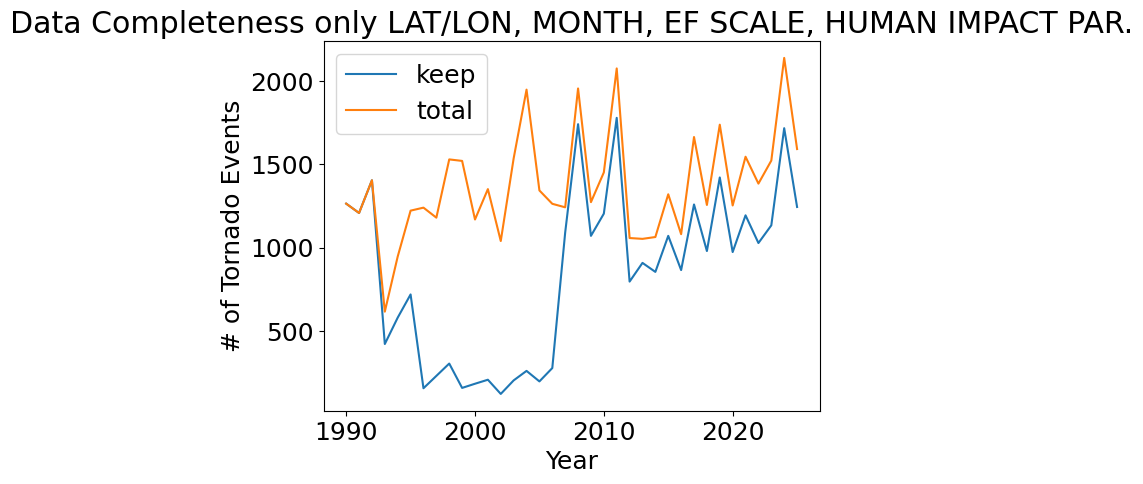

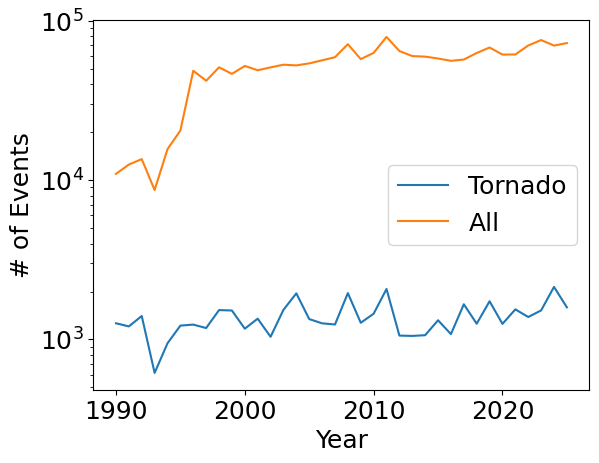

In [5]:
plt.figure()
plt.plot(year_sing, Nkeep, label='keep')
plt.plot(year_sing, Nall, label='total')
plt.legend()
plt.xlabel('Year')
plt.ylabel('# of Tornado Events')
plt.title('Data Completeness only LAT/LON, MONTH, EF SCALE, HUMAN IMPACT PAR.')

plt.figure()
plt.plot(year_sing, np.array(Nall), label='Tornado')
plt.plot(year_sing, np.array(Nevents), label='All')
plt.legend()
plt.yscale('log')
plt.xlabel('Year')
plt.ylabel('# of Events')

In [6]:
years_all = np.concatenate(years_all, axis = -1)
months_all = np.concatenate(months_all, axis = -1)
radar_dist_all = np.concatenate(radar_dist_all, axis = -1)
#source_all = np.concatenate(source_all, axis = -1)
b_lat = np.concatenate(b_lat, axis = -1)
b_lon = np.concatenate(b_lon, axis = -1)
#e_lat = np.concatenate(e_lat, axis = -1)
#e_lon = np.concatenate(e_lon, axis = -1)
tor_all = np.concatenate(tor_all, axis = -1)
d_direct = np.concatenate(d_direct, axis = -1)
d_indirect = np.concatenate(d_indirect, axis = -1)
inj_direct = np.concatenate(inj_direct, axis = -1)
inj_indirect = np.concatenate(inj_indirect, axis = -1)
d_property = np.concatenate(d_property, axis = -1)
d_crops = np.concatenate(d_crops, axis = -1)
radar_all = np.concatenate(radar_all, axis = -1)

In [7]:
df_impact = pd.DataFrame({
    'YEAR': years_all, 
    'MONTH': months_all, 
    'RADAR_DIST': radar_dist_all,
    'BEGIN_LAT': b_lat, 
    'BEGIN_LON': b_lon, 
    'TOR_F_SCALE': tor_all,
    'DEATHS_DIRECT': d_direct, 
    'DEATHS_INDIRECT': d_indirect, 
    'INJURIES_DIRECT': inj_direct, 
    'INJURIES_INDIRECT': inj_indirect, 
    'DAMAGE_PROPERTY': d_property, 
    'DAMAGE_CROPS': d_crops, 
    'RADAR_COV': radar_all, 
})
df_impact.to_csv('../data/processed/tornadoes_all_humanimpact.csv', index=True)

# If we are modelling only the number of tornadoes (per season OR of a certain EF scale) over years, we can filter the data even less and only require LAT, LON, EF scale, and Month

In [8]:
raw_files = glob.glob('../data/raw/StormEvents*')
raw_files = np.sort(raw_files) # will sort chronologically thanks to naming convention
print(raw_files)

savekeys = ['BEGIN_YEARMONTH', 'BEGIN_LAT', 'BEGIN_LON',
            'TOR_F_SCALE',
           ]

listsave = []
Nlistsave = []


years_all = []
months_all = []
radar_dist_all = []
source_all = []
b_lat = []
b_lon = []
e_lat = []
e_lon = []
source_all = []
tor_all = []
d_direct = []
d_indirect = []
inj_direct = []
inj_indirect = []
d_property = []
d_crops = []
radar_all = []

# data completeness 
year_sing = []
Nkeep = []
Nall = []

Nevents = []
for n in raw_files:
    inFile = n
    info = pd.read_csv(inFile, encoding = 'latin-1')
    
    other, inYear = inFile.split('.0_d')
    inYear, other = inYear.split('_c')
    print('====== DATA FOR YEAR: ', inYear, ' ======')
    #store[inYear] = {}

    Ntot = len(info)
    Nevents.append(Ntot)
    Ntornado = np.sum(info['EVENT_TYPE'] == 'Tornado')
    
    # filter data frame
    tornado_df = info[info['EVENT_TYPE'] == 'Tornado']

    Nall.append(len(tornado_df))

    passin_all = []
    passinN_all = []

    filter_arr = np.array(tornado_df['BEGIN_LAT'].isna() == False) * np.array(tornado_df['BEGIN_LON'].isna() == False)
    filter_arr = filter_arr * np.array(tornado_df['TOR_F_SCALE'].isna() == False)

    year_sing.append(int(inYear))
    Nkeep.append(np.sum(filter_arr))
    
    m_int = 0
    store = {}
    data_f = tornado_df[filter_arr]

    print(Nall[-1], 'out of ', Ntot,  'are tornado events, or {:.2f}%'.format(Nall[-1]/Ntot*100))
    print(Nkeep[-1], 'out of ', Nall[-1],  ' tornado events TO KEEP, or {:.2f}%'.format(Nkeep[-1]/Nall[-1]*100))
    
    for m in savekeys:
        passin_all.append(len(tornado_df[m][tornado_df[m].isna() == False])/Ntornado*100)
        passinN_all.append(len(tornado_df[m][tornado_df[m].isna() == False]))
        m_int += 1
        years = []
        months = []
        if m == 'BEGIN_YEARMONTH':
            ym = np.asarray(data_f[m], dtype=int)

            years = ym // 100
            months = ym % 100
            store['YEAR'] = years
            store['MONTH'] = months
        else:    
            store[m] = data_f[m]

    lats = data_f['BEGIN_LAT']
    lons = data_f['BEGIN_LON']
    
    points = gpd.GeoDataFrame(
        geometry=[Point(lon, lat) for lon, lat in zip(lons, lats)],
        crs=gdf.crs
    )
    
    joined = gpd.sjoin(
        points,
        gdf,
        predicate="within",
        how="left"
    )
    
    inside_polygon = (
        joined.groupby(joined.index)["index_right"] # prevents duplicates (of points which intersect with lat/lon )
        .apply(lambda x: x.notna().any()) # flags whether any of the points intersects with the lat/lon
        .reindex(points.index, fill_value=False) # for any lat/lon which don't have matches, fill in with False 
        .to_numpy()
    )

    tornado_coords = np.column_stack((lats, lons))
    radar_coords_deg = radar_coords[:, :2]   # latitude, longitude
    
    tornado_rad = np.radians(tornado_coords) # convert from deg to radians
    radar_rad = np.radians(radar_coords_deg)
    
    dist_rad = haversine_distances(tornado_rad, radar_rad) # angular distances [radians]
    
    dist_nearest_radar = np.sort(dist_rad * R_earth, axis=-1)[:,0] # [km]

    store['TOR_F_SCALE'] = [str(i).replace('E','') for i in store['TOR_F_SCALE']]
    store['TOR_F_SCALE'] = [str(i).replace('F','') for i in store['TOR_F_SCALE']]
    store['TOR_F_SCALE'] = [str(i).replace('U','-1') for i in store['TOR_F_SCALE']]
    store['TOR_F_SCALE'] = [int(i) for i in store['TOR_F_SCALE']]

    years_all.append(np.array((store['YEAR'])))
    months_all.append(np.array((store['MONTH'])))
    b_lat.append(np.array((store['BEGIN_LAT'])))
    b_lon.append(np.array((store['BEGIN_LON'])))
    tor_all.append(np.array((store['TOR_F_SCALE'])))

    df = pd.DataFrame(store)
    df.to_csv('../data/processed/per_year/'+inYear+'_tornados.csv', index=False)
    
    listsave.append(np.array(passin_all))
    Nlistsave.append(np.array(passinN_all))

['../data/raw/StormEvents_details-ftp_v1.0_d1990_c20260323.csv.gz'
 '../data/raw/StormEvents_details-ftp_v1.0_d1991_c20260323.csv.gz'
 '../data/raw/StormEvents_details-ftp_v1.0_d1992_c20260323.csv.gz'
 '../data/raw/StormEvents_details-ftp_v1.0_d1993_c20260323.csv.gz'
 '../data/raw/StormEvents_details-ftp_v1.0_d1994_c20260323.csv.gz'
 '../data/raw/StormEvents_details-ftp_v1.0_d1995_c20260323.csv.gz'
 '../data/raw/StormEvents_details-ftp_v1.0_d1996_c20260323.csv.gz'
 '../data/raw/StormEvents_details-ftp_v1.0_d1997_c20260323.csv.gz'
 '../data/raw/StormEvents_details-ftp_v1.0_d1998_c20260323.csv.gz'
 '../data/raw/StormEvents_details-ftp_v1.0_d1999_c20260323.csv.gz'
 '../data/raw/StormEvents_details-ftp_v1.0_d2000_c20260323.csv.gz'
 '../data/raw/StormEvents_details-ftp_v1.0_d2001_c20260323.csv.gz'
 '../data/raw/StormEvents_details-ftp_v1.0_d2002_c20260323.csv.gz'
 '../data/raw/StormEvents_details-ftp_v1.0_d2003_c20260323.csv.gz'
 '../data/raw/StormEvents_details-ftp_v1.0_d2004_c20260323.csv

/tmp/ipykernel_542048/22734043.py:39: DtypeWarning: Columns (0: SOURCE, 1: EPISODE_NARRATIVE) have mixed types. Specify dtype option on import or set low_memory=False.
  info = pd.read_csv(inFile, encoding = 'latin-1')


====== DATA FOR YEAR:  1995  ======
1222 out of  20464 are tornado events, or 5.97%
725 out of  1222  tornado events TO KEEP, or 59.33%


/tmp/ipykernel_542048/22734043.py:39: DtypeWarning: Columns (0: SOURCE, 1: MAGNITUDE_TYPE) have mixed types. Specify dtype option on import or set low_memory=False.
  info = pd.read_csv(inFile, encoding = 'latin-1')


====== DATA FOR YEAR:  1996  ======
1240 out of  48534 are tornado events, or 2.55%
1238 out of  1240  tornado events TO KEEP, or 99.84%


...

====== DATA FOR YEAR:  1997  ======
1180 out of  41991 are tornado events, or 2.81%
1180 out of  1180  tornado events TO KEEP, or 100.00%


/tmp/ipykernel_542048/22734043.py:39: DtypeWarning: Columns (0: MAGNITUDE_TYPE) have mixed types. Specify dtype option on import or set low_memory=False.
  info = pd.read_csv(inFile, encoding = 'latin-1')


====== DATA FOR YEAR:  1998  ======
1529 out of  50973 are tornado events, or 3.00%
1529 out of  1529  tornado events TO KEEP, or 100.00%
====== DATA FOR YEAR:  1999  ======
1520 out of  46383 are tornado events, or 3.28%
1517 out of  1520  tornado events TO KEEP, or 99.80%
====== DATA FOR YEAR:  2000  ======
1169 out of  52007 are tornado events, or 2.25%
1157 out of  1169  tornado events TO KEEP, or 98.97%
====== DATA FOR YEAR:  2001  ======
1351 out of  48875 are tornado events, or 2.76%
1336 out of  1351  tornado events TO KEEP, or 98.89%
====== DATA FOR YEAR:  2002  ======
1040 out of  50936 are tornado events, or 2.04%
1034 out of  1040  tornado events TO KEEP, or 99.42%
====== DATA FOR YEAR:  2003  ======
1535 out of  52956 are tornado events, or 2.90%
1494 out of  1535  tornado events TO KEEP, or 97.33%
====== DATA FOR YEAR:  2004  ======
1947 out of  52409 are tornado events, or 3.72%
1910 out of  1947  tornado events TO KEEP, or 98.10%
====== DATA FOR YEAR:  2005  ======
1343

/tmp/ipykernel_542048/22734043.py:39: DtypeWarning: Columns (0: FLOOD_CAUSE, 1: TOR_OTHER_WFO, 2: TOR_OTHER_CZ_STATE, 3: TOR_OTHER_CZ_NAME) have mixed types. Specify dtype option on import or set low_memory=False.
  info = pd.read_csv(inFile, encoding = 'latin-1')


====== DATA FOR YEAR:  2006  ======
1263 out of  56400 are tornado events, or 2.24%
1256 out of  1263  tornado events TO KEEP, or 99.45%
====== DATA FOR YEAR:  2007  ======
1242 out of  59011 are tornado events, or 2.10%
1242 out of  1242  tornado events TO KEEP, or 100.00%
====== DATA FOR YEAR:  2008  ======
1954 out of  71190 are tornado events, or 2.74%
1954 out of  1954  tornado events TO KEEP, or 100.00%
====== DATA FOR YEAR:  2009  ======
1273 out of  57398 are tornado events, or 2.22%
1273 out of  1273  tornado events TO KEEP, or 100.00%
====== DATA FOR YEAR:  2010  ======
1451 out of  62809 are tornado events, or 2.31%
1451 out of  1451  tornado events TO KEEP, or 100.00%
====== DATA FOR YEAR:  2011  ======
2074 out of  79091 are tornado events, or 2.62%
2074 out of  2074  tornado events TO KEEP, or 100.00%
====== DATA FOR YEAR:  2012  ======
1058 out of  64503 are tornado events, or 1.64%
1058 out of  1058  tornado events TO KEEP, or 100.00%
====== DATA FOR YEAR:  2013  ======

Text(0, 0.5, '# of Events')

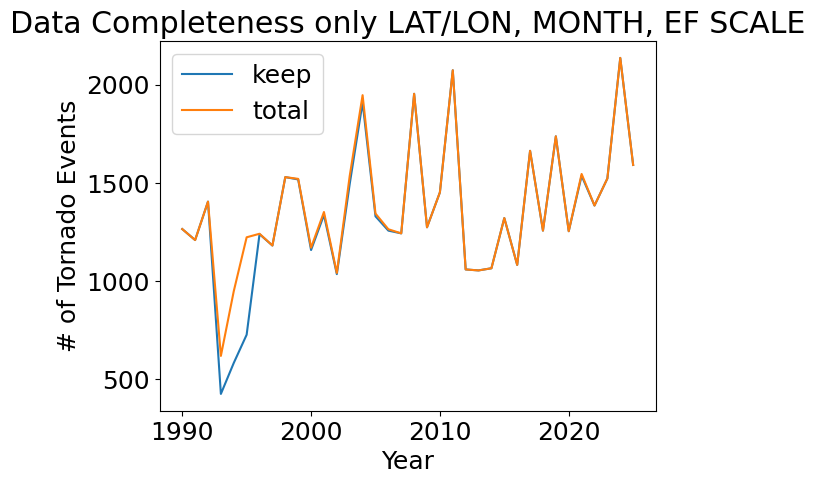

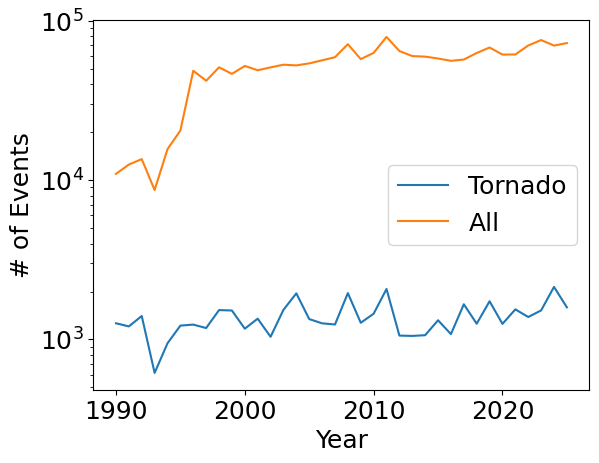

In [9]:
plt.figure()
plt.plot(year_sing, Nkeep, label='keep')
plt.plot(year_sing, Nall, label='total')
plt.legend()
plt.xlabel('Year')
plt.ylabel('# of Tornado Events')
plt.title('Data Completeness only LAT/LON, MONTH, EF SCALE')


plt.figure()
plt.plot(year_sing, np.array(Nall), label='Tornado')
plt.plot(year_sing, np.array(Nevents), label='All')
plt.legend()
plt.yscale('log')
plt.xlabel('Year')
plt.ylabel('# of Events')

In [10]:
years_all = np.concatenate(years_all, axis = -1)
months_all = np.concatenate(months_all, axis = -1)
b_lat = np.concatenate(b_lat, axis = -1)
b_lon = np.concatenate(b_lon, axis = -1)
tor_all = np.concatenate(tor_all, axis = -1)

In [11]:
len(years_all) # size of total data set

48234

In [12]:
df = pd.DataFrame({
    'YEAR': years_all, 
    'MONTH': months_all,
    'BEGIN_LAT': b_lat, 
    'BEGIN_LON': b_lon,  
    'TOR_F_SCALE': tor_all, 
})
df.to_csv('../data/processed/tornadoes_all.csv', index=True)